### Marker gene identification with COSG

##### Setting basics

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
sc.set_figure_params(dpi=80,dpi_save=300,color_map='Spectral_r',facecolor='white')
from matplotlib import rcParams

# To modify the default figure size, use rcParams
rcParams['figure.figsize'] = 4, 4
#rcParams['font.sans-serif'] = 'Arial'
#rcParams['font.family'] = 'Arial'
sc.settings.verbosity = 3
sc.logging.print_header()

Component,Info
Python,"3.10.16 (main, Dec 11 2024, 16:24:50) [GCC 11.2.0]"
OS,Linux-6.8.0-52-generic-x86_64-with-glibc2.35
CPU,"128 logical CPU cores, x86_64"
GPU,"ID: 0, NVIDIA GeForce RTX 3090, Driver: 535.230.02, Memory: 24576 MiB"
Updated,2025-04-03 23:53
Dependency,Version
jedi,0.19.1
PyYAML,6.0.2
psutil,6.0.0
kiwisolver,1.4.5


In [2]:
### Palette
scane_color=["#e6194b","#3cb44b","#ffe119",
"#4363d8","#f58231","#911eb4",
"#46f0f0","#f032e6","#bcf60c",
"#fabebe","#008080","#e6beff",
"#9a6324",
             "#800000",
"#aaffc3","#808000","#ffd8b1",
"#000075","#808080"
            ]
import seaborn as sns
self_palette2=sns.color_palette(np.hstack((scane_color,sc.pl.palettes.godsnot_102)))

#### Load the data

In [3]:
rna_pp = sc.read("../../../4-2-concatenation-rna-prot/results/adata_hvg_anno.h5ad")
rna_pp

AnnData object with n_obs × n_vars = 95125 × 2099
    obs: 'sample_id', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', '_scvi_batch', '_scvi_labels', 'doublet', 'size_factors', 'coarse_anno', 'fine_anno'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization', 'soupX_counts'

#### Import COSG

In [4]:
import cosg

In [6]:
rna_pp.obs["coarse_anno"].value_counts()

coarse_anno
T cells     55011
NK cells    14908
Mo cells    14129
B cells      8188
NKT          2189
DCs           463
ILCs          237
Name: count, dtype: int64

In [7]:
t_adata = rna_pp[rna_pp.obs["coarse_anno"] == "T cells"]
t_adata

View of AnnData object with n_obs × n_vars = 55011 × 2099
    obs: 'sample_id', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', '_scvi_batch', '_scvi_labels', 'doublet', 'size_factors', 'coarse_anno', 'fine_anno'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_deviant', 'binomial_deviance', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg'
    layers: 'analytic_pearson_residuals', 'log1p_norm', 'raw_counts', 'scran_normalization', 'soupX_counts'

In [9]:
t_adata.obs["fine_anno"].value_counts()

fine_anno
CD4_TEMRA        10924
CD4_Naive_T       9568
Naive_CD8         7966
CD4_Tem           5970
CD4_Tscm          4198
Tem_CD8           3392
Effect_CD8        3377
CD4_Tcm           2997
Exhausted_CD8     2291
gd_T cells        1564
CD4_Treg          1468
Tcm_CD8            967
CD4_TTE            298
CD4_TTM             31
Name: count, dtype: int64

In [10]:
fine2gdt = {
    "CD4_TEMRA": "abt",
    "CD4_Naive_T": "abt",
    "Naive_CD8": "abt",
    "CD4_Tem": "abt",
    "CD4_Tscm": "abt",
    "Tem_CD8": "abt",
    "Effect_CD8": "abt",
    "CD4_Tcm": "abt",
    "Exhausted_CD8": "abt",
    "gd_T cells": "gdt",
    "CD4_Treg": "abt",
    "Tcm_CD8": "abt",
    "CD4_TTE": "abt",
    "CD4_TTM": "abt",
}
t_adata.obs["gd_anno"] = t_adata.obs["fine_anno"].map(fine2gdt)
t_adata.obs["gd_anno"].value_counts()

/tmp/ipykernel_394214/2797462010.py:17: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  t_adata.obs["gd_anno"] = t_adata.obs["fine_anno"].map(fine2gdt)


gd_anno
abt    53447
gdt     1564
Name: count, dtype: int64

In [11]:
%%time
groupby='gd_anno'
cosg.cosg(t_adata,
         key_added='cosg',
         # use_raw=False, layer='log1p', ## e.g., if you want to use the log1p layer in adata
         mu=100,
         expressed_pct=0.1,
         remove_lowly_expressed=True,
         n_genes_user=100, ### Use all the genes, to enable the calculation of transformed COSG scores
         # n_genes_user=100,
         groupby=groupby,
         return_by_group=True,
         verbosity=1
)

Finished identifying marker genes by COSG, and the results are in adata.uns['cosg'].
CPU times: user 801 ms, sys: 249 ms, total: 1.05 s
Wall time: 1.05 s


让我们用点图可视化由COSG识别的顶级标记基因。构建树状图有两种方式，一种是使用use_rep，另一种是使用adata.obs[groupby]中的类别顺序。

这里是使用`use_rep`来指定低维代表点图的显示:

In [12]:
sc.pp.pca(t_adata, svd_solver="arpack", use_highly_variable=True, layer="scran_normalization")

computing PCA
    with n_comps=50


/home/data/frankie/anaconda3/envs/marker-gene-identify/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:439: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


    finished (0:00:10)


In [14]:
t_adata.obs['gd_anno'] = t_adata.obs['gd_anno'].astype('category')

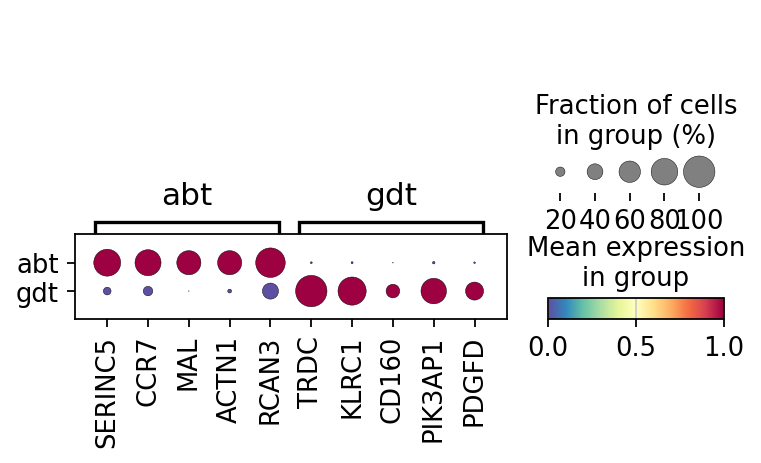

In [16]:
cosg.plotMarkerDotplot(
    t_adata,
    groupby='gd_anno',
    top_n_genes=5,
    key_cosg='cosg',
    use_rep='X_pca',
    swap_axes=False,
    standard_scale='var',
    cmap='Spectral_r',
    save="pictures/coarse_markers.pdf"
)

使用`adata.obs['grouby']中的顺序`

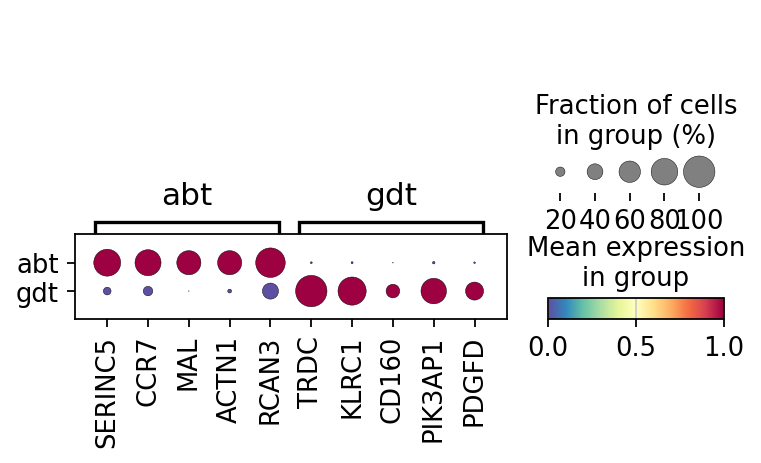

In [17]:
cosg.plotMarkerDotplot(
    t_adata,
    groupby='gd_anno',
    top_n_genes=5,
    key_cosg='cosg',
    use_rep=None,
    swap_axes=False,
    standard_scale='var',
    cmap='Spectral_r',
    # save='test.pdf'
)

检查最具有代表性的标志基因:

In [19]:
coarse_markers = pd.DataFrame(t_adata.uns['cosg']['names']).head(45)
coarse_markers

,abt,gdt
0,SERINC5,TRDC
1,CCR7,KLRC1
2,MAL,CD160
3,ACTN1,PIK3AP1
4,RCAN3,PDGFD
5,CD4,CNR2
6,TRABD2A,DTHD1
7,LEF1,XCL2
8,CHMP7,IL12RB2
9,PRKCA,IL18RAP


In [20]:
# 创建一个空列表来存储结果  
cell_types = []  
marker_genes = []  

# 遍历原始DataFrame的每一列（细胞类型）和对应的基因  
for cell_type, genes in coarse_markers.items():  
    for gene in genes:  
        cell_types.append(cell_type)  
        marker_genes.append(gene)  

# 创建新的DataFrame  
marker_gene_df = pd.DataFrame({  
    'cell_type': cell_types,  
    'marker_gene': marker_genes  
})  

# 显示结果  
print(marker_gene_df.head(10))  
print(f"\nDataFrame总行数: {len(marker_gene_df)}")

  cell_type marker_gene
0       abt     SERINC5
1       abt        CCR7
2       abt         MAL
3       abt       ACTN1
4       abt       RCAN3
5       abt         CD4
6       abt     TRABD2A
7       abt        LEF1
8       abt       CHMP7
9       abt       PRKCA

DataFrame总行数: 90


In [21]:
marker_gene_df.to_csv("results/gdt_abt_marker_45.csv", header=True, index=True)

In [22]:
marker_gene_df.shape

(90, 2)

genes_series.to_pickle("results/nkt_t_genes.npy")

检查相应的COSG评分

In [ ]:
pd.DataFrame(rna_pp.uns['cosg']['scores']).head()

如果设置`return_by_group=True`（默认情况下），`COSG`结果也会以多索引`Pandas`数据框格式保存，您可以通过以下方式访问它：

In [ ]:
rna_pp.uns['cosg']['COSG'].head()

同样地,你可以通过下面的代码提取基因名或者评分:

#### Calculate normalized COSG scores for each gene across all cell types

除了COSG分数，还可以计算标准化COSG分数（或转换后的COSG分数）以实现基因表达特异性的跨细胞类型比较。这也可能使跨数据集或跨研究的表达特异性比较成为可能。

注意：在`cosg.cosg()`函数中设置`n_genes_user = adata.n_vars`是计算标准化`COSG`分数所必需的。

我们首先通过使用相同的基因索引对标记基因数据框进行重新索引，其中的值是各个细胞类型中的`COSG`分数：

In [ ]:
cosg_scores=cosg.indexByGene(
    rna_pp.uns['cosg']['COSG'],
    # gene_key="names", score_key="scores",
    set_nan_to_zero=True,
    convert_negative_one_to_zero=True
)

In [ ]:
cosg_scores.head()

接下来,我们对COSG评分进行标准化:

In [ ]:
cosg_scores=cosg.iqrLogNormalize(cosg_scores)

In [ ]:
cosg_scores.head()

让我们查看几个基因的标准化评分:

In [ ]:
gene_check=np.ravel(pd.DataFrame(rna_pp.uns['cosg']['names'])[:3].values.T)[:10]

In [ ]:
cosg_scores.loc[gene_check].T.head()

这里是标准化前的`COSG`分数，它们不能直接在细胞类型之间进行比较，因为它们受到细胞数量和细胞簇相似性等因素的影响。

In [ ]:
cosg_scores_original=cosg.indexByGene(
    rna_pp.uns['cosg']['COSG'],
    # gene_key="names", score_key="scores",
    set_nan_to_zero=True,
    convert_negative_one_to_zero=True
)
cosg_scores_original.loc[gene_check].T.head()

#### Visualizing the marker genes with plotMarkerDendrogram

COSG提供一种直观的可视化，包含标记基因名称、COSG分数和细胞簇相似性：

In [ ]:
cosg.plotMarkerDendrogram(
     rna_pp,
     group_by="coarse_anno",
     use_rep="X_pca",
     calculate_dendrogram_on_cosg_scores=False,
     top_n_genes=5,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     # collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s',
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

您可以通过cmap设置基因节点颜色，并通过hierarchy_merge_scale合并层次树状图。参数hierarchy_merge_scale（0到1）控制基于距离相似性将二元节点合并为多子节点：

In [ ]:
cosg.plotMarkerDendrogram(
     rna_pp,
     group_by="coarse_anno",
     use_rep="X_pca",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=5,
     radius_step=1.5,
     cmap="Spectral_r",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0.2,
     # collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # figure_size= (8, 8),
     # node_shape_cell_type='o',
     # node_shape_gene='s',
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

您也可以通过将`collapse_scale`设置为0到1之间的值来折叠树状图：

In [ ]:
cosg.plotMarkerDendrogram(
     rna_pp,
     group_by="coarse_anno",
     use_rep="X_pca",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=5,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.2,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s',
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

参数`collapse_scale`控制细胞类型的聚类分辨率，较大的值会导致更多的聚类：

In [ ]:
cosg.plotMarkerDendrogram(
     rna_pp,
     group_by="coarse_anno",
     use_rep="X_pca",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=5,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.8,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     # node_shape_cell_type='o',
     # node_shape_gene='s',
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

细胞类型节点和基因节点的形状可以分别通过node_shape_cell_type和node_shape_gene来调整：

In [ ]:
cosg.plotMarkerDendrogram(
     rna_pp,
     group_by="coarse_anno",
     use_rep="X_pca",
     calculate_dendrogram_on_cosg_scores=True,
     top_n_genes=5,
     radius_step=1.5,
     cmap="Purples",
     gene_label_offset=0.25,
     gene_label_color="black",
     linkage_method="ward",
     distance_metric="correlation",
     hierarchy_merge_scale=0,
     collapse_scale=0.8,
     add_cluster_node_for_single_node_cluster=True,
     palette=None,
     figure_size= (10, 10),
     node_shape_cell_type='d',
     node_shape_gene='^',
     colorbar_width=0.01,
     gene_color_min=0,
     gene_color_max=None,
     show_figure=True,
     # save='./markerDendrogram.pdf',
)

coarse_marker_gene = cosg_scores
coarse_marker_gene.head()

coarse_marker_gene

In [ ]:
cosg_scores_original

In [ ]:
cosg_scores_original.loc[gene_check].T

In [ ]:
pd.DataFrame(rna_pp.uns['cosg']['names'])

In [ ]:
pd.DataFrame(rna_pp.uns['cosg']['names'])

In [ ]:
adata

In [ ]:
adata.write_h5ad("results/nkt_t.h5ad")

In [23]:
t_adata.write_h5ad("results/gdt_t.h5ad")